<a href="https://colab.research.google.com/github/lswoodentoys/research_paper/blob/main/B%E1%BA%A3ng_t%E1%BB%95ng_h%E1%BB%A3p_h%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dữ liệu ban đầu:
   Wavelength_nm  I_G177  I_UVA340
0            280     0.0       0.0
1            281     0.0       0.0
2            282     0.0       0.0
3            283     0.0       0.0
4            284     0.0       0.0


BẢNG SO SÁNH HỆ SỐ TƯƠNG ĐỒNG PHỔ
Wavelength_Range  Lambda_Min_nm  Lambda_Max_nm  Number_of_Data_Points  Chi_Square_Sum  Standard_Deviation          R
      295-330 nm            295            330                     36      0.29800276          0.09227331 0.90772669
      295-320 nm            295            320                     26      0.24244274          0.09847695 0.90152305
      295-310 nm            295            310                     16      0.15369619          0.10122456 0.89877544
      295-300 nm            295            300                      6      0.07161905          0.11968212 0.88031788
      295-340 nm            295            340                     46      0.84227249          0.13681070 0.86318930
      295-350 nm            295    

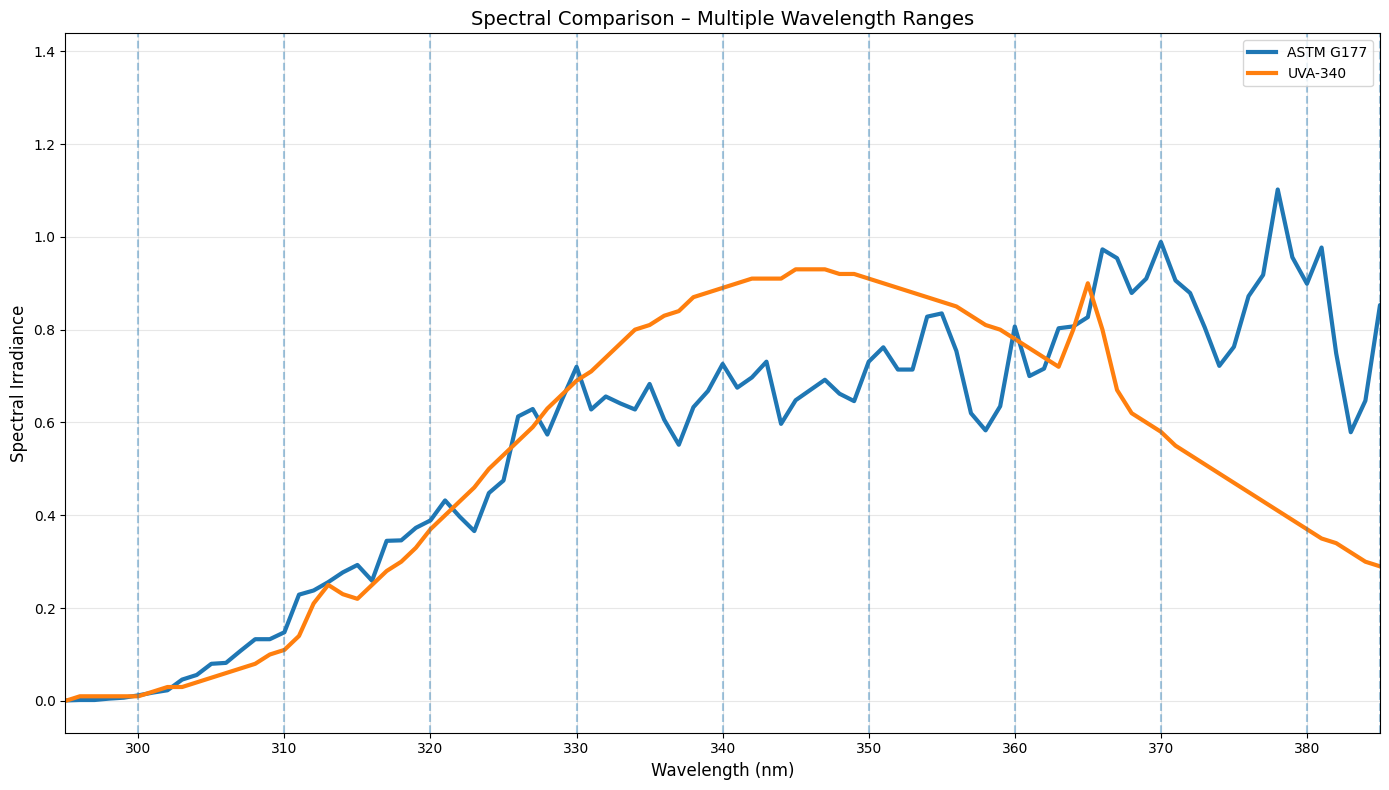

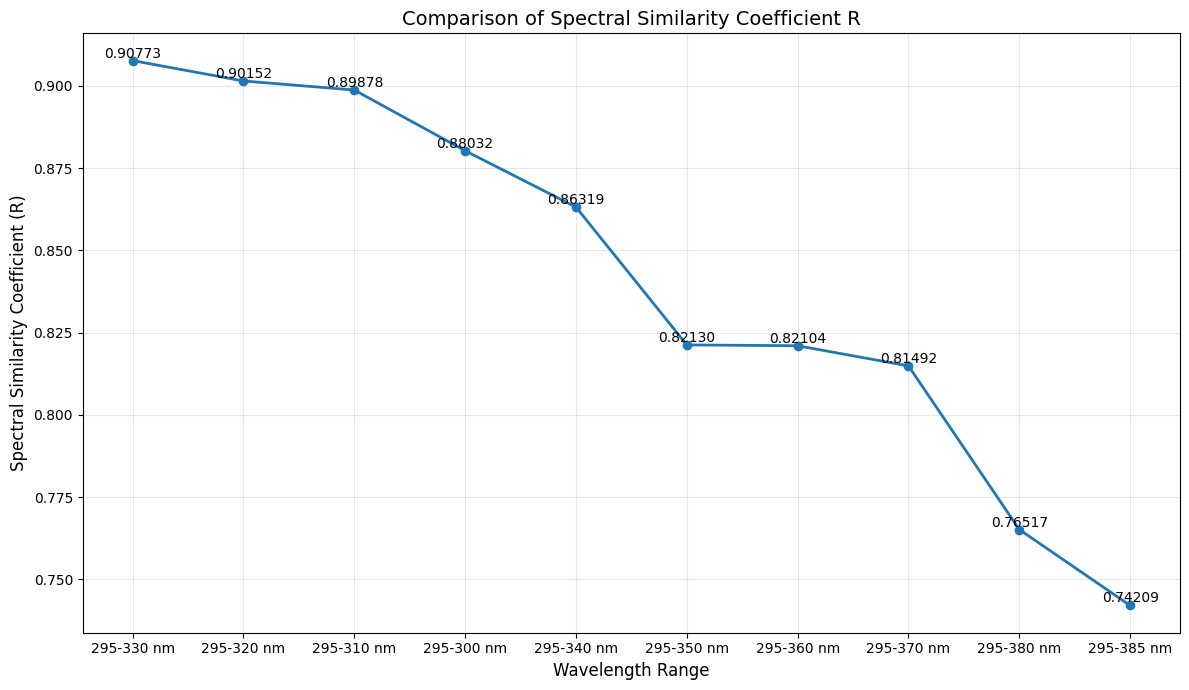

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. ĐỌC DỮ LIỆU PHỔ
# ============================================================

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

# Làm sạch tên cột
df.columns = df.columns.str.strip()

print("Dữ liệu ban đầu:")
print(df.head())


# ============================================================
# 2. CHUYỂN DỮ LIỆU SANG NUMERIC
# ============================================================

columns = [
    "Wavelength_nm",
    "I_G177",
    "I_UVA340"
]

for col in columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 3. LOẠI BỎ DỮ LIỆU KHÔNG HỢP LỆ
# ============================================================

df = df.dropna(
    subset=columns
).copy()

# I_G177 phải > 0
df = df[
    df["I_G177"] > 0
].copy()

# Sắp xếp theo wavelength
df = df.sort_values(
    "Wavelength_nm"
)

# Nếu wavelength trùng nhau → lấy trung bình
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[
    ["I_G177", "I_UVA340"]
].mean()


# ============================================================
# 4. CÁC KHOẢNG BƯỚC SÓNG MUỐN SO SÁNH
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 5. TÍNH R CHO TỪNG KHOẢNG
# ============================================================

results = []

calculation_details = {}


for lambda_max in lambda_max_list:

    # --------------------------------------------------------
    # Lọc dữ liệu theo khoảng wavelength
    # --------------------------------------------------------

    df_range = df[
        (df["Wavelength_nm"] >= lambda_min) &
        (df["Wavelength_nm"] <= lambda_max)
    ].copy()


    # Kiểm tra dữ liệu
    if len(df_range) < 2:

        print(
            f"WARNING: Không đủ dữ liệu "
            f"cho {lambda_min}-{lambda_max} nm"
        )

        continue


    # --------------------------------------------------------
    # Difference
    # --------------------------------------------------------

    df_range["Difference"] = (
        df_range["I_G177"]
        -
        df_range["I_UVA340"]
    )


    # --------------------------------------------------------
    # Squared Difference
    # --------------------------------------------------------

    df_range["Squared_Difference"] = (
        df_range["Difference"] ** 2
    )


    # --------------------------------------------------------
    # Chi-square term
    # --------------------------------------------------------

    df_range["Chi_Square_Term"] = (
        df_range["Squared_Difference"]
        /
        df_range["I_G177"]
    )


    # --------------------------------------------------------
    # Tổng Chi-square
    # --------------------------------------------------------

    chi_square_sum = (
        df_range["Chi_Square_Term"].sum()
    )


    # --------------------------------------------------------
    # Denominator
    # --------------------------------------------------------

    denominator = (
        lambda_max
        -
        lambda_min
    )


    # --------------------------------------------------------
    # Standard deviation
    # --------------------------------------------------------

    standard_deviation = np.sqrt(
        chi_square_sum
        /
        denominator
    )


    # --------------------------------------------------------
    # R
    # --------------------------------------------------------

    R = 1 - standard_deviation


    # --------------------------------------------------------
    # Lưu kết quả
    # --------------------------------------------------------

    results.append({

        "Wavelength_Range":
            f"{lambda_min}-{lambda_max} nm",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            lambda_max,

        "Number_of_Data_Points":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "Standard_Deviation":
            standard_deviation,

        "R":
            R

    })


    # --------------------------------------------------------
    # Lưu bảng tính chi tiết
    # --------------------------------------------------------

    calculation_details[
        f"{lambda_min}-{lambda_max}"
    ] = df_range.copy()


# ============================================================
# 6. TẠO BẢNG SO SÁNH
# ============================================================

results_df = pd.DataFrame(
    results
)


# Sắp xếp theo R từ lớn → nhỏ
results_df = results_df.sort_values(
    by="R",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 7. HIỂN THỊ BẢNG
# ============================================================

print("\n")
print("=" * 90)
print("BẢNG SO SÁNH HỆ SỐ TƯƠNG ĐỒNG PHỔ")
print("=" * 90)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.8f}"
    )
)


# ============================================================
# 8. XUẤT BẢNG SO SÁNH RA CSV
# ============================================================

results_df.to_csv(
    "spectral_R_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nĐã xuất:"
    " spectral_R_comparison.csv"
)


# ============================================================
# 9. XUẤT TOÀN BỘ KẾT QUẢ CHI TIẾT
# ============================================================

with pd.ExcelWriter(
    "spectral_R_comparison.xlsx",
    engine="openpyxl"
) as writer:

    # Bảng tổng hợp
    results_df.to_excel(
        writer,
        sheet_name="R_Comparison",
        index=False
    )

    # Từng khoảng phổ
    for range_name, detail_df in calculation_details.items():

        sheet_name = (
            f"{range_name}_nm"
        )

        detail_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )


print(
    "Đã xuất:"
    " spectral_R_comparison.xlsx"
)


# ============================================================
# 10. BIỂU ĐỒ NHIỀU DẢI PHỔ
# ============================================================

plt.figure(
    figsize=(14, 8)
)


# ------------------------------------------------------------
# Vẽ phổ ASTM G177 và UVA-340
# ------------------------------------------------------------

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    label="ASTM G177",
    linewidth=3
)

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    label="UVA-340",
    linewidth=3
)


# ------------------------------------------------------------
# Đánh dấu các giới hạn wavelength
# ------------------------------------------------------------

for lambda_max in lambda_max_list:

    plt.axvline(
        x=lambda_max,
        linestyle="--",
        alpha=0.4
    )


# ------------------------------------------------------------
# Thiết lập biểu đồ
# ------------------------------------------------------------

plt.xlabel(
    "Wavelength (nm)",
    fontsize=12
)

plt.ylabel(
    "Spectral Irradiance",
    fontsize=12
)

plt.title(
    "Spectral Comparison – Multiple Wavelength Ranges",
    fontsize=14
)

plt.xlim(
    lambda_min,
    max(lambda_max_list)
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()


# Lưu hình
plt.savefig(
    "spectral_multiple_ranges.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. BIỂU ĐỒ SO SÁNH R
# ============================================================

plt.figure(
    figsize=(12, 7)
)


plt.plot(
    results_df["Wavelength_Range"],
    results_df["R"],
    marker="o",
    linewidth=2
)


# Hiển thị giá trị R trên từng điểm
for i, row in results_df.iterrows():

    plt.text(
        i,
        row["R"],
        f'{row["R"]:.5f}',
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xlabel(
    "Wavelength Range",
    fontsize=12
)

plt.ylabel(
    "Spectral Similarity Coefficient (R)",
    fontsize=12
)

plt.title(
    "Comparison of Spectral Similarity Coefficient R",
    fontsize=14
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    "R_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#BẢNG SO SÁNH GIỮA UVA 340NM VỚI THƯ VIỆN PVLIB


===== UVA-340 DATA =====
   Wavelength_nm  I_UVA340
0            295      0.00
1            296      0.01
2            297      0.01
3            298      0.01
4            299      0.01

===== ASTM G173-03 FROM PVLIB =====
            extraterrestrial        global        direct
wavelength                                              
280.0                  0.082  4.730900e-23  2.536100e-26
280.5                  0.099  1.230700e-21  1.091700e-24
281.0                  0.150  5.689500e-21  6.125300e-24
281.5                  0.212  1.566200e-19  2.747900e-22
282.0                  0.267  1.194600e-18  2.834600e-21

===== WAVELENGTH RANGE =====
UVA-340:
295 - 360 nm
AM1.5:
280.0 - 4000.0 nm

===== SYNCHRONIZED SPECTRA =====
    Wavelength_nm  I_UVA340    I_AM15
0           295.0     0.000  0.000012
1           295.5     0.005  0.000028
2           296.0     0.010  0.000048
3           296.5     0.010  0.000071
4           297.0     0.010  0.000097
5           297.5     0.010  0.000186

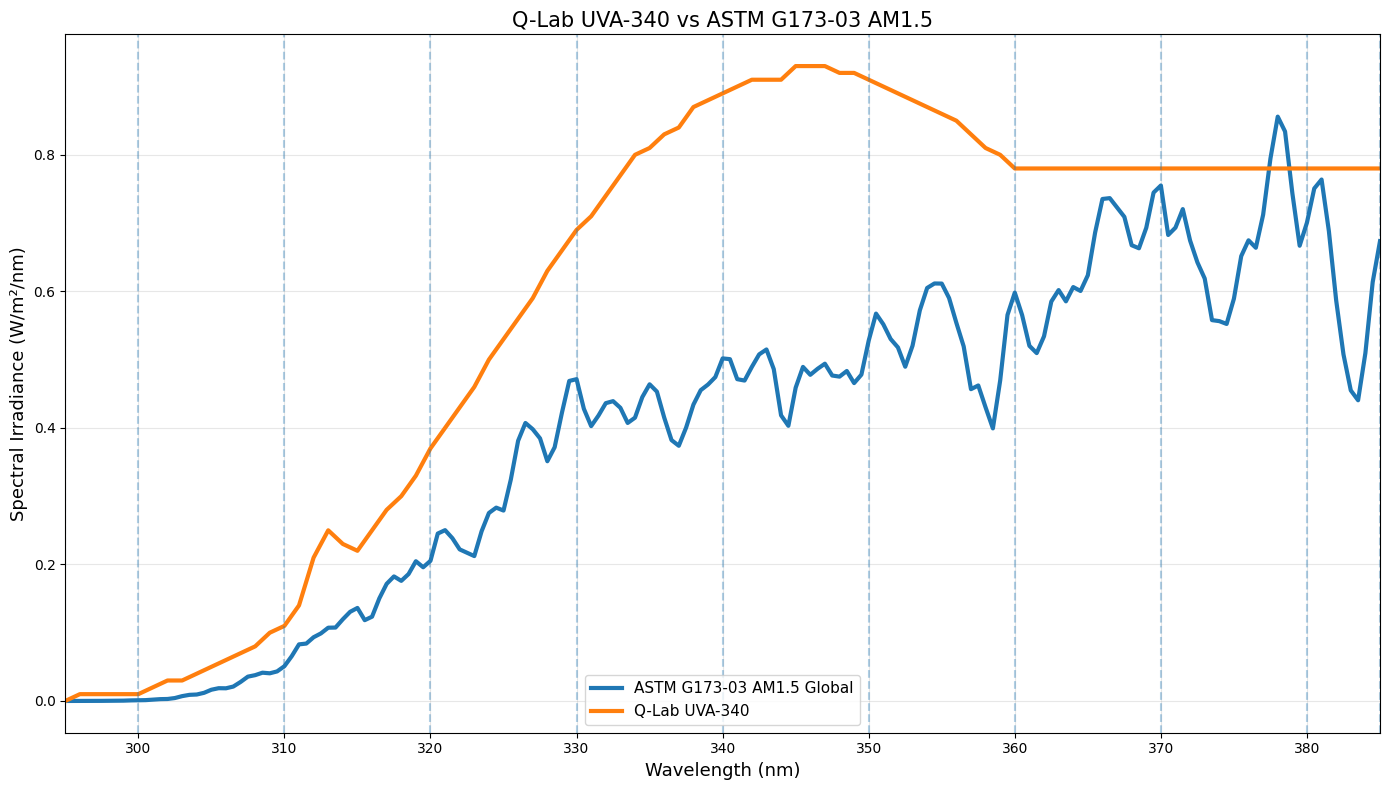

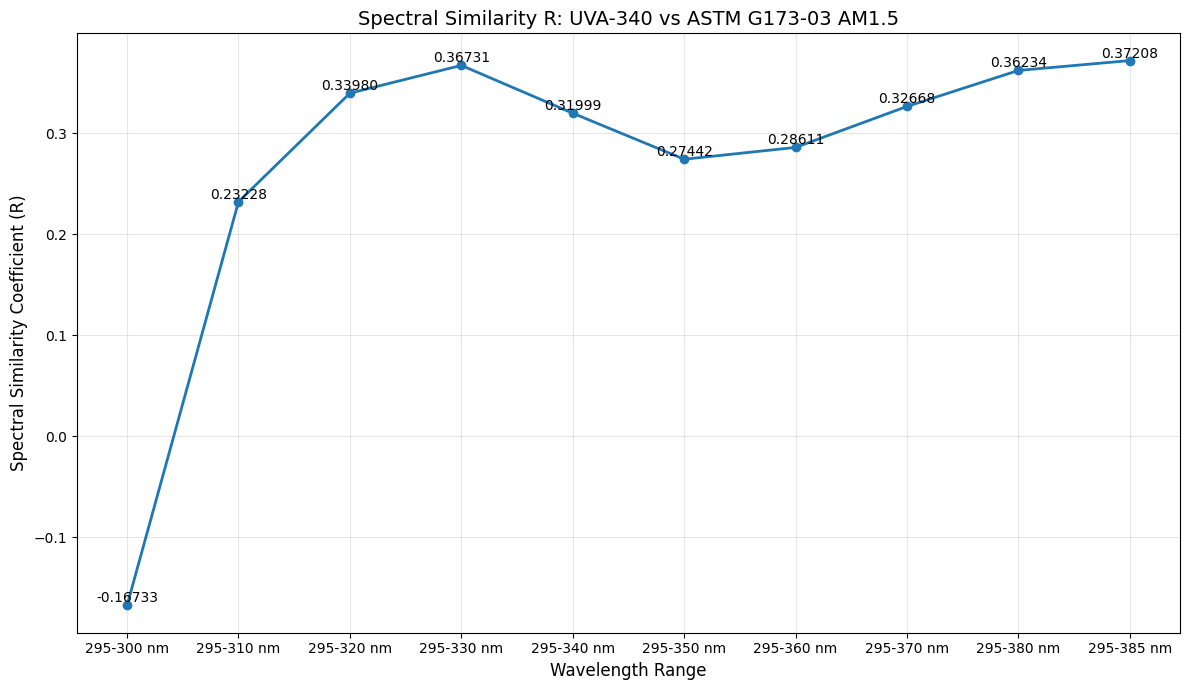



GIÁ TRỊ R
     295-300 nm : R = -0.16732890
     295-310 nm : R = 0.23227639
     295-320 nm : R = 0.33979517
     295-330 nm : R = 0.36731336
     295-340 nm : R = 0.31999337
     295-350 nm : R = 0.27442151
     295-360 nm : R = 0.28610849
     295-370 nm : R = 0.32667959
     295-380 nm : R = 0.36233551
     295-385 nm : R = 0.37208470

Hoàn thành phân tích.


In [ ]:
# ============================================================
# SO SÁNH PHỔ UVA-340 Q-LAB VỚI ASTM G173-03 AM1.5
# Sử dụng pvlib.spectrum.get_reference_spectra()
#
# UVA-340:
#   Dữ liệu SPD từ Q-Lab
#
# AM1.5:
#   ASTM G173-03 từ pvlib
#
# Tính:
#   Chi-square
#   Standard deviation
#   R = 1 - standard deviation
#
# Các khoảng:
#   từ 295-300 nm và các giá trị tăng dần mỗi lần 10 nm đến giá trị cao nhất là 385 nm
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Nếu chưa cài pvlib:
!pip install pvlib

import pvlib


# ============================================================
# 1. THIẾT LẬP FILE UVA-340 CỦA Q-LAB
# ============================================================

# File CSV của bạn phải có 2 cột:
#
# Wavelength_nm
# I_UVA340
#
# Ví dụ:
#
# Wavelength_nm,I_UVA340
# 295,0.00
# 296,0.01
# 297,0.01
# ...
# 340,0.89
# ...

# Tải file UV340 của QLab lên Google Drive, theo đường dẫn bên dưới.

uva_file = '/content/drive/MyDrive/Python_study/datasets/UVA340_QLab.csv'


# ============================================================
# 2. ĐỌC DỮ LIỆU UVA-340
# ============================================================

uva = pd.read_csv(
    uva_file
)

# Làm sạch tên cột
uva.columns = uva.columns.str.strip()

print("\n===== UVA-340 DATA =====")
print(uva.head())


# ============================================================
# 3. CHUYỂN SANG NUMERIC
# ============================================================

uva["Wavelength_nm"] = pd.to_numeric(
    uva["Wavelength_nm"],
    errors="coerce"
)

uva["I_UVA340"] = pd.to_numeric(
    uva["I_UVA340"],
    errors="coerce"
)


# Loại dữ liệu không hợp lệ
uva = uva.dropna(
    subset=[
        "Wavelength_nm",
        "I_UVA340"
    ]
).copy()


# Sắp xếp wavelength
uva = uva.sort_values(
    "Wavelength_nm"
)


# Nếu wavelength bị trùng → lấy trung bình
uva = uva.groupby(
    "Wavelength_nm",
    as_index=False
)["I_UVA340"].mean()


# ============================================================
# 4. LẤY ASTM G173-03 AM1.5 TỪ PVLIB
# ============================================================

am15 = pvlib.spectrum.get_reference_spectra(
    standard="ASTM G173-03"
)


print("\n===== ASTM G173-03 FROM PVLIB =====")
print(am15.head())


# ============================================================
# 5. CHUYỂN AM1.5 THÀNH DATAFRAME
# ============================================================

am15 = am15.reset_index()

am15 = am15.rename(
    columns={
        "wavelength": "Wavelength_nm"
    }
)


# Chúng ta sử dụng:
#
# AM1.5 GLOBAL
#
# thay vì:
# extraterrestrial
# direct
#
# ASTM G173-03 global là hemispherical
# irradiance trên bề mặt nghiêng 37°.


am15 = am15[
    [
        "Wavelength_nm",
        "global"
    ]
].copy()


am15 = am15.rename(
    columns={
        "global": "I_AM15"
    }
)


# ============================================================
# 6. KIỂM TRA DẢI WAVELENGTH
# ============================================================

print("\n===== WAVELENGTH RANGE =====")

print(
    "UVA-340:"
)

print(
    f"{uva['Wavelength_nm'].min()} - "
    f"{uva['Wavelength_nm'].max()} nm"
)

print(
    "AM1.5:"
)

print(
    f"{am15['Wavelength_nm'].min()} - "
    f"{am15['Wavelength_nm'].max()} nm"
)


# ============================================================
# 7. CÁC KHOẢNG PHỔ CẦN SO SÁNH
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 8. TẠO WAVELENGTH GRID CHUNG
# ============================================================

# Lấy toàn bộ wavelength của UVA-340
# và AM1.5 trong vùng cần nghiên cứu.

combined_wavelength = np.union1d(
    uva["Wavelength_nm"].values,
    am15["Wavelength_nm"].values
)


combined_wavelength = combined_wavelength[
    (
        combined_wavelength >= lambda_min
    )
    &
    (
        combined_wavelength <= max(
            lambda_max_list
        )
    )
]


# ============================================================
# 9. INTERPOLATE HAI PHỔ VỀ CÙNG WAVELENGTH
# ============================================================

# UVA-340
uva_interp = np.interp(
    combined_wavelength,
    uva["Wavelength_nm"],
    uva["I_UVA340"]
)


# AM1.5
am15_interp = np.interp(
    combined_wavelength,
    am15["Wavelength_nm"],
    am15["I_AM15"]
)


# Tạo dataframe chung

spectra = pd.DataFrame({

    "Wavelength_nm":
        combined_wavelength,

    "I_UVA340":
        uva_interp,

    "I_AM15":
        am15_interp
})


# ============================================================
# 10. KIỂM TRA DỮ LIỆU
# ============================================================

print("\n===== SYNCHRONIZED SPECTRA =====")

print(
    spectra.head(20)
)


# ============================================================
# 11. TÍNH R CHO TỪNG KHOẢNG
# ============================================================

results = []

calculation_details = {}


for lambda_max in lambda_max_list:

    print(
        "\n"
        + "=" * 70
    )



    print(
        "=" * 70
    )


    # --------------------------------------------------------
    # Lọc khoảng wavelength
    # --------------------------------------------------------

    df_range = spectra[
        (
            spectra["Wavelength_nm"]
            >= lambda_min
        )
        &
        (
            spectra["Wavelength_nm"]
            <= lambda_max
        )
    ].copy()


    # --------------------------------------------------------
    # Kiểm tra
    # --------------------------------------------------------

    if len(df_range) < 2:

        print(
            "Không đủ dữ liệu."
        )

        continue


    # --------------------------------------------------------
    # Loại bỏ AM1.5 <= 0
    #
    # Tránh chia cho 0
    # --------------------------------------------------------

    df_range = df_range[
        df_range["I_AM15"] > 0
    ].copy()


    # --------------------------------------------------------
    # Difference
    #
    # AM1.5 - UVA340
    # --------------------------------------------------------

    df_range["Difference"] = (
        df_range["I_AM15"]
        -
        df_range["I_UVA340"]
    )


    # --------------------------------------------------------
    # Squared Difference
    # --------------------------------------------------------

    df_range[
        "Squared_Difference"
    ] = (
        df_range["Difference"] ** 2
    )


    # --------------------------------------------------------
    # Chi-square term
    #
    # Theo công thức:
    #
    # (AM1.5 - UVA340)^2 / AM1.5
    #
    # --------------------------------------------------------

    df_range[
        "Chi_Square_Term"
    ] = (
        df_range["Squared_Difference"]
        /
        df_range["I_AM15"]
    )


    # --------------------------------------------------------
    # Tổng Chi-square
    # --------------------------------------------------------

    chi_square_sum = (
        df_range[
            "Chi_Square_Term"
        ].sum()
    )


    # --------------------------------------------------------
    # Denominator
    # --------------------------------------------------------

    denominator = (
        lambda_max
        -
        lambda_min
    )


    # --------------------------------------------------------
    # Standard deviation
    # --------------------------------------------------------

    standard_deviation = np.sqrt(
        chi_square_sum
        /
        denominator
    )


    # --------------------------------------------------------
    # R
    # --------------------------------------------------------

    R = (
        1
        -
        standard_deviation
    )


    # --------------------------------------------------------
    # Lưu kết quả
    # --------------------------------------------------------

    results.append({

        "Wavelength_Range":
            f"{lambda_min}-{lambda_max} nm",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            lambda_max,

        "Number_of_Data_Points":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "Standard_Deviation":
            standard_deviation,

        "R":
            R
    })


    # --------------------------------------------------------
    # Lưu chi tiết
    # --------------------------------------------------------

    calculation_details[
        f"{lambda_min}-{lambda_max}"
    ] = df_range.copy()


# ============================================================
# 12. TẠO BẢNG TỔNG HỢP
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 13. SẮP XẾP R TỪ LỚN → NHỎ
# ============================================================

results_df = results_df.sort_values(
    by="R",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 14. HIỂN THỊ BẢNG
# ============================================================

print("\n\n")

print(
    "=" * 100
)

print(
    "BẢNG SO SÁNH UVA-340 VÀ ASTM G173-03 AM1.5"
)

print(
    "=" * 100
)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.8f}"
    )
)


# ============================================================
# 15. LƯU CSV
# ============================================================

results_df.to_csv(
    "UVA340_vs_AM15_R_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 16. LƯU EXCEL
# ============================================================

excel_file = (
    "UVA340_vs_AM15_analysis.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    # --------------------------------------------------------
    # Sheet 1: Summary
    # --------------------------------------------------------

    results_df.to_excel(
        writer,
        sheet_name="R_Comparison",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 2: Synchronized spectra
    # --------------------------------------------------------

    spectra.to_excel(
        writer,
        sheet_name="Synchronized_Spectra",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 3 trở đi:
    # Chi tiết từng khoảng
    # --------------------------------------------------------

    for range_name, detail_df in (
        calculation_details.items()
    ):

        sheet_name = (
            f"{range_name}_nm"
        )

        detail_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )


print(
    "\nĐã xuất Excel:"
)

print(
    excel_file
)


# ============================================================
# 17. BIỂU ĐỒ 1:
# UVA-340 vs AM1.5
# ============================================================

plt.figure(
    figsize=(14, 8)
)


plt.plot(
    spectra["Wavelength_nm"],
    spectra["I_AM15"],
    label="ASTM G173-03 AM1.5 Global",
    linewidth=3
)


plt.plot(
    spectra["Wavelength_nm"],
    spectra["I_UVA340"],
    label="Q-Lab UVA-340",
    linewidth=3
)


# ------------------------------------------------------------
# Các giới hạn wavelength
# ------------------------------------------------------------

for lambda_max in lambda_max_list:

    plt.axvline(
        x=lambda_max,
        linestyle="--",
        alpha=0.35
    )


# ------------------------------------------------------------
# 295 nm
# ------------------------------------------------------------

plt.axvline(
    x=295,
    linestyle="--",
    alpha=0.35
)


plt.xlabel(
    "Wavelength (nm)",
    fontsize=13
)

plt.ylabel(
    "Spectral Irradiance "
    "(W/m²/nm)",
    fontsize=13
)

plt.title(
    "Q-Lab UVA-340 vs ASTM G173-03 AM1.5",
    fontsize=15
)


plt.xlim(
    295,
    385
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend(
    fontsize=11
)


plt.tight_layout()


plt.savefig(
    "UVA340_vs_AM15_spectrum.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 18. BIỂU ĐỒ 2:
# SO SÁNH R
# ============================================================

# Sắp xếp theo wavelength để biểu đồ
# đi từ 340 → 385

plot_R = results_df.sort_values(
    "Lambda_Max_nm"
).copy()


plt.figure(
    figsize=(12, 7)
)


plt.plot(
    plot_R["Wavelength_Range"],
    plot_R["R"],
    marker="o",
    linewidth=2
)


# ------------------------------------------------------------
# Hiển thị R trên từng điểm
# ------------------------------------------------------------

for i, row in plot_R.iterrows():

    plt.text(
        row["Wavelength_Range"],
        row["R"],
        f'{row["R"]:.5f}',
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xlabel(
    "Wavelength Range",
    fontsize=12
)

plt.ylabel(
    "Spectral Similarity Coefficient (R)",
    fontsize=12
)

plt.title(
    "Spectral Similarity R: "
    "UVA-340 vs ASTM G173-03 AM1.5",
    fontsize=14
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.savefig(
    "UVA340_vs_AM15_R_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 19. IN KẾT QUẢ R RIÊNG
# ============================================================

print("\n")
print(
    "=" * 70
)

print(
    "GIÁ TRỊ R"
)

print(
    "=" * 70
)


for _, row in plot_R.iterrows():

    print(
        f"{row['Wavelength_Range']:>15}"
        f" : R = {row['R']:.8f}"
    )


print(
    "\nHoàn thành phân tích."
)


#BẢNG SO SÁNH KẾT QUẢ TỔNG HỢP



STANDARDIZED DATA
   Wavelength_nm  I_UVA340    I_AM15
0            295      0.00  0.000012
1            296      0.01  0.000048
2            297      0.01  0.000097
3            298      0.01  0.000290
4            299      0.01  0.000492
5            300      0.01  0.001020
6            301      0.02  0.001930
7            302      0.03  0.002921
8            303      0.03  0.007095
9            304      0.04  0.009470

Total wavelength points:
66

Wavelength range:
295.0 - 360.0 nm

CALCULATING 295-300 nm

CALCULATING 295-310 nm

CALCULATING 295-320 nm

CALCULATING 295-330 nm

CALCULATING 295-340 nm

CALCULATING 295-350 nm

CALCULATING 295-360 nm

CALCULATING 295-370 nm

CALCULATING 295-380 nm

CALCULATING 295-385 nm



SELECTION MATRIX
Wavelength_Range  Spectral_R R > 0.90  Pearson_r Pearson r > 0.90  Spearman_rho Spearman ρ > 0.90  R_squared R² > 0.90 All 4 Conditions
      295-300 nm    0.143414       NO   0.400360               NO      0.654654                NO   0.160288    

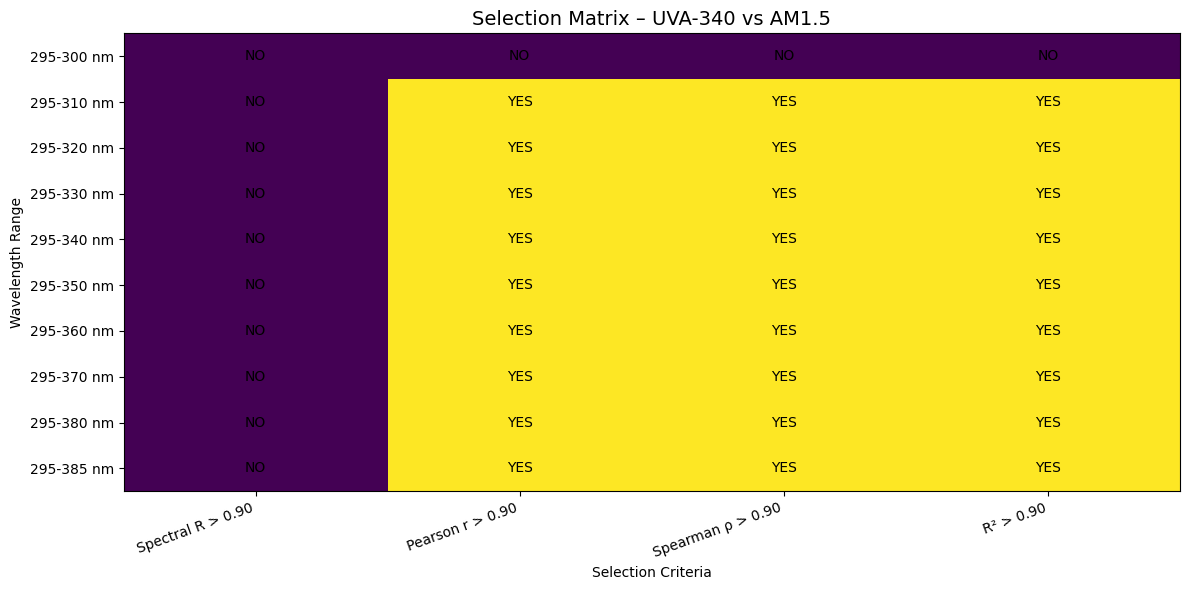




FINAL SELECTION SUMMARY
Không có dải phổ nào thỏa cả 4 điều kiện.


Bạn có thể xem xét các dải trong bảng Selection Matrix trước khi lựa chọn dải cuối cùng.


In [ ]:
# ============================================================
# STANDARDIZED SPECTRAL COMPARISON
#
# Q-Lab UVA-340
#        VS
# ASTM G173-03 AM1.5 Global
#
# Metrics:
#   1. Spectral Similarity R
#   2. Pearson r
#   3. Spearman rho
#   4. R²
#
# Wavelength ranges: từ 295nm đến 385nm
# Main purpose:
#   Identify wavelength range suitable for subsequent
#   spectral correlation analysis.
# ============================================================


# ============================================================
# 0. INSTALL / IMPORT
# ============================================================

# Nếu Colab báo thiếu pvlib, chạy dòng dưới một lần:
!pip install pvlib openpyxl scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib

from scipy.stats import pearsonr
from scipy.stats import spearmanr


# ============================================================
# 1. Q-LAB UVA-340 FILE
# ============================================================

uva_file = (
    "/content/drive/MyDrive/Python_study/"
    "datasets/UVA340_QLab.csv"
)


# ============================================================
# 2. READ UVA-340 DATA
# ============================================================

uva = pd.read_csv(
    uva_file
)

uva.columns = (
    uva.columns
    .str.strip()
)


# ============================================================
# 3. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Wavelength_nm",
    "I_UVA340"
]

missing_columns = [
    col
    for col in required_columns
    if col not in uva.columns
]

if missing_columns:

    raise ValueError(
        "Thiếu các cột: "
        + str(missing_columns)
    )


# ============================================================
# 4. CONVERT DATA TO NUMERIC
# ============================================================

uva["Wavelength_nm"] = pd.to_numeric(
    uva["Wavelength_nm"],
    errors="coerce"
)

uva["I_UVA340"] = pd.to_numeric(
    uva["I_UVA340"],
    errors="coerce"
)


# ============================================================
# 5. REMOVE INVALID DATA
# ============================================================

uva = uva.dropna(
    subset=[
        "Wavelength_nm",
        "I_UVA340"
    ]
).copy()


# ============================================================
# 6. SORT WAVELENGTH
# ============================================================

uva = uva.sort_values(
    "Wavelength_nm"
)


# ============================================================
# 7. REMOVE DUPLICATE WAVELENGTHS
# ============================================================

uva = uva.groupby(
    "Wavelength_nm",
    as_index=False
)["I_UVA340"].mean()


# ============================================================
# 8. ANALYSIS WAVELENGTH
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 9. GET ASTM G173-03 AM1.5
# ============================================================

am15_all = (
    pvlib.spectrum.get_reference_spectra(
        standard="ASTM G173-03"
    )
)


# ============================================================
# 10. SELECT AM1.5 GLOBAL
# ============================================================

am15_global = (
    am15_all["global"]
)


# ============================================================
# 11. LIMIT UVA DATA
# ============================================================

uva = uva[
    (
        uva["Wavelength_nm"]
        >= lambda_min
    )
    &
    (
        uva["Wavelength_nm"]
        <= max(lambda_max_list)
    )
].copy()


# ============================================================
# 12. INTERPOLATE AM1.5
#     TO UVA-340 WAVELENGTH GRID
# ============================================================

am15_interp = np.interp(
    uva["Wavelength_nm"].values,
    am15_all.index.values,
    am15_global.values
)


# ============================================================
# 13. CREATE STANDARDIZED DATASET
# ============================================================

spectra = pd.DataFrame({

    "Wavelength_nm":
        uva["Wavelength_nm"].values,

    "I_UVA340":
        uva["I_UVA340"].values,

    "I_AM15":
        am15_interp

})


# ============================================================
# 14. BASIC CHECK
# ============================================================

print("\n")
print("=" * 90)
print("STANDARDIZED DATA")
print("=" * 90)

print(
    spectra.head(10)
)

print("\nTotal wavelength points:")
print(
    len(spectra)
)

print("\nWavelength range:")
print(
    f"{spectra['Wavelength_nm'].min():.1f}"
    f" - "
    f"{spectra['Wavelength_nm'].max():.1f} nm"
)

# ============================================================
# 15. TÍNH R, PEARSON R, SPEARMAN RHO, R^2 CHO TỪNG KHOẢNG
# ============================================================

results = []

calculation_details = {}


for lambda_max in lambda_max_list:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"CALCULATING {lambda_min}-{lambda_max} nm"
    )

    print(
        "=" * 70
    )


    # --------------------------------------------------------
    # Lọc khoảng wavelength
    # --------------------------------------------------------

    df_range = spectra[
        (
            spectra["Wavelength_nm"]
            >= lambda_min
        )
        &
        (
            spectra["Wavelength_nm"]
            <= lambda_max
        )
    ].copy()


    # --------------------------------------------------------
    # Kiểm tra
    # --------------------------------------------------------

    if len(df_range) < 2:

        print(
            "Không đủ dữ liệu."
        )

        continue


    # --------------------------------------------------------
    # Loại bỏ AM1.5 <= 0
    #
    # Tránh chia cho 0
    # --------------------------------------------------------

    df_range = df_range[
        df_range["I_AM15"] > 0
    ].copy()


    # Đảm bảo vẫn còn dữ liệu sau khi lọc
    if len(df_range) < 2:
        print(f"Không đủ dữ liệu sau khi loại bỏ I_AM15 <= 0 cho {lambda_min}-{lambda_max} nm.")
        continue


    # --------------------------------------------------------
    # Difference
    #
    # AM1.5 - UVA340
    # --------------------------------------------------------

    df_range["Difference"] = (
        df_range["I_AM15"]
        -
        df_range["I_UVA340"]
    )


    # --------------------------------------------------------
    # Squared Difference
    # --------------------------------------------------------

    df_range[
        "Squared_Difference"
    ] = (
        df_range["Difference"] ** 2
    )


    # --------------------------------------------------------
    # Chi-square term
    #
    # Theo công thức:
    #
    # (AM1.5 - UVA340)^2 / AM1.5
    #
    # --------------------------------------------------------

    df_range[
        "Chi_Square_Term"
    ] = (
        df_range["Squared_Difference"]
        /
        df_range["I_AM15"]
    )


    # --------------------------------------------------------
    # Tổng Chi-square
    # --------------------------------------------------------

    chi_square_sum = (
        df_range[
            "Chi_Square_Term"
        ].sum()
    )


    # --------------------------------------------------------
    # Denominator
    # --------------------------------------------------------

    denominator = (
        lambda_max
        -
        lambda_min
    )

    # Tránh chia cho 0
    if denominator == 0:
        print(f"WARNING: Mẫu số bằng 0 cho {lambda_min}-{lambda_max} nm. Không thể tính Standard Deviation và Spectral_R.")
        standard_deviation = np.nan
        R = np.nan
    else:
        # --------------------------------------------------------
        # Standard deviation
        # --------------------------------------------------------

        standard_deviation = np.sqrt(
            chi_square_sum
            /
            denominator
        )


        # --------------------------------------------------------
        # Spectral Similarity R
        # --------------------------------------------------------

        R = (
            1
            -
            standard_deviation
        )

    # --------------------------------------------------------
    # Calculate Pearson, Spearman, and R-squared
    # --------------------------------------------------------
    if len(df_range) > 1:
        pearson_r, pearson_p = pearsonr(df_range["I_AM15"], df_range["I_UVA340"])
        spearman_rho, spearman_p = spearmanr(df_range["I_AM15"], df_range["I_UVA340"])
        R_squared = pearson_r**2
    else:
        pearson_r, pearson_p = np.nan, np.nan
        spearman_rho, spearman_p = np.nan, np.nan
        R_squared = np.nan


    # --------------------------------------------------------
    # Lưu kết quả
    # --------------------------------------------------------

    results.append({

        "Wavelength_Range":
            f"{lambda_min}-{lambda_max} nm",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            lambda_max,

        "Number_of_Data_Points":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "Standard_Deviation":
            standard_deviation,

        "Spectral_R": # Changed 'R' to 'Spectral_R' here
            R,
        "Pearson_r":
            pearson_r,
        "Pearson_p":
            pearson_p,
        "Spearman_rho":
            spearman_rho,
        "Spearman_p":
            spearman_p,
        "R_squared":
            R_squared
    })


    # --------------------------------------------------------
    # Lưu chi tiết
    # --------------------------------------------------------

    calculation_details[
        f"{lambda_min}-{lambda_max}"
    ] = df_range.copy()


# ============================================================
# 16. TẠO BẢNG TỔNG HỢP
# ============================================================

results_df = pd.DataFrame(
    results
)


# ============================================================
# 17. DEFINE THE 4 SELECTION CONDITIONS
# ============================================================

# Condition 1:
# Spectral similarity R > 0.90

results_df["Condition_R"] = (
    results_df["Spectral_R"] > 0.90
)


# Condition 2:
# Pearson r > 0.90

results_df["Condition_Pearson"] = (
    results_df["Pearson_r"] > 0.90
)


# Condition 3:
# Spearman rho > 0.90

results_df["Condition_Spearman"] = (
    results_df["Spearman_rho"] > 0.90
)


# Condition 4:
# R² > 0.90

results_df["Condition_R2"] = (
    results_df["R_squared"] > 0.90
)


# ============================================================
# 18. CREATE YES / NO COLUMNS
# ============================================================

results_df["R > 0.90"] = np.where(
    results_df["Condition_R"],
    "YES",
    "NO"
)


results_df["Pearson r > 0.90"] = np.where(
    results_df["Condition_Pearson"],
    "YES",
    "NO"
)


results_df["Spearman ρ > 0.90"] = np.where(
    results_df["Condition_Spearman"],
    "YES",
    "NO"
)


results_df["R² > 0.90"] = np.where(
    results_df["Condition_R2"],
    "YES",
    "NO"
)


# ============================================================
# 19. ALL FOUR CONDITIONS
# ============================================================

results_df["All_4_Conditions"] = (
    results_df["Condition_R"]
    &
    results_df["Condition_Pearson"]
    &
    results_df["Condition_Spearman"]
    &
    results_df["Condition_R2"]
)


results_df["All 4 Conditions"] = np.where(
    results_df["All_4_Conditions"],
    "YES",
    "NO"
)


# ============================================================
# 20. SORT BY WAVELENGTH
# ============================================================

results_by_wavelength = (
    results_df
    .sort_values(
        "Lambda_Max_nm"
    )
    .reset_index(drop=True)
)


# ============================================================
# 21. CREATE SELECTION MATRIX
# ============================================================

selection_matrix = results_by_wavelength[
    [
        "Wavelength_Range",

        "Spectral_R",
        "R > 0.90",

        "Pearson_r",
        "Pearson r > 0.90",

        "Spearman_rho",
        "Spearman ρ > 0.90",

        "R_squared",
        "R² > 0.90",

        "All 4 Conditions"
    ]
].copy()


# ============================================================
# 22. DISPLAY SELECTION MATRIX
# ============================================================

print("\n\n")

print("=" * 130)

print(
    "SELECTION MATRIX"
)

print("=" * 130)


print(
    selection_matrix.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# ============================================================
# 23. IDENTIFY RANGES PASSING ALL 4 CONDITIONS
# ============================================================

qualified_all = results_by_wavelength[
    results_by_wavelength[
        "All_4_Conditions"
    ]
].copy()


# ============================================================
# 24. DISPLAY QUALIFIED RANGES
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "WAVELENGTH RANGES PASSING ALL 4 CONDITIONS"
)

print("=" * 100)


if len(qualified_all) > 0:

    print(
        qualified_all[
            [
                "Wavelength_Range",
                "Spectral_R",
                "Pearson_r",
                "Spearman_rho",
                "R_squared"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
            f"{x:.8f}"
        )
    )

else:

    print(
        "Không có dải phổ nào "
        "thỏa cả 4 điều kiện."
    )


# ============================================================n# 25. COUNT CONDITIONS PASSED
# ============================================================

results_by_wavelength[
    "Conditions_Passed"
] = (
    results_by_wavelength[
        [
            "Condition_R",
            "Condition_Pearson",
            "Condition_Spearman",
            "Condition_R2"
        ]
    ]
    .sum(axis=1)
)


# ============================================================
# 26. CREATE CONDITION SCORE
# ============================================================

# 4/4 = pass all conditions
# 3/4 = pass three conditions
# 2/4 = pass two conditions
# etc.

results_by_wavelength[
    "Condition_Score"
] = (
    results_by_wavelength[
        "Conditions_Passed"
    ].astype(str)
    +
    "/4"
)


# ============================================================
# 27. CREATE EXTENDED SELECTION MATRIX
# ============================================================

selection_matrix_extended = (
    results_by_wavelength[
        [
            "Wavelength_Range",

            "Spectral_R",
            "R > 0.90",

            "Pearson_r",
            "Pearson r > 0.90",

            "Spearman_rho",
            "Spearman ρ > 0.90",

            "R_squared",
            "R² > 0.90",

            "Conditions_Passed",
            "Condition_Score",

            "All 4 Conditions"
        ]
    ]
    .copy()
)


# ============================================================
# 28. DISPLAY EXTENDED MATRIX
# ============================================================

print("\n\n")

print("=" * 140)

print(
    "EXTENDED SELECTION MATRIX"
)

print("=" * 140)


print(
    selection_matrix_extended.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.6f}"
    )
)


# ============================================================
# 29. SORT BY NUMBER OF CONDITIONS PASSED
# ============================================================

selection_ranked = (
    results_by_wavelength
    .sort_values(
        [
            "Conditions_Passed",
            "Spectral_R",
            "Pearson_r",
            "Spearman_rho"
        ],
        ascending=[
            False,
            False,
            False,
            False
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 30. DISPLAY RANKED CANDIDATES
# ============================================================

print("\n\n")

print("=" * 110)

print(
    "CANDIDATE RANGES SORTED BY CONDITIONS PASSED"
)

print("=" * 110)


print(
    selection_ranked[
        [
            "Wavelength_Range",
            "Conditions_Passed",
            "Condition_Score",
            "Spectral_R",
            "Pearson_r",
            "Spearman_rho",
            "R_squared",
            "All 4 Conditions"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
        f"{x:.8f}"
    )
)


# ============================================================
# 31. EXPORT SELECTION MATRIX TO CSV
# ============================================================

selection_matrix_extended.to_csv(
    "UVA340_AM15_Selection_Matrix.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 32. EXPORT QUALIFIED RANGES
# ============================================================

qualified_all[
    [
        "Wavelength_Range",
        "Spectral_R",
        "Pearson_r",
        "Pearson_p",
        "Spearman_rho",
        "Spearman_p",
        "R_squared"
    ]
].to_csv(
    "UVA340_AM15_All_4_Conditions_Passed.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 33. EXPORT RANKED CANDIDATES
# ============================================================

selection_ranked[
    [
        "Wavelength_Range",
        "Conditions_Passed",
        "Condition_Score",
        "Spectral_R",
        "Pearson_r",
        "Spearman_rho",
        "R_squared",
        "All 4 Conditions"
    ]
].to_csv(
    "UVA340_AM15_Candidate_Ranges.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 34. CREATE FINAL EXCEL FILE
# ============================================================

excel_file = (
    "UVA340_AM15_SELECTION_MATRIX.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:


    # --------------------------------------------------------
    # Sheet 1
    # All metrics
    # --------------------------------------------------------

    results_by_wavelength.to_excel(
        writer,
        sheet_name="All_Metrics",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 2
    # Selection Matrix
    # --------------------------------------------------------

    selection_matrix_extended.to_excel(
        writer,
        sheet_name="Selection_Matrix",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 3
    # All 4 conditions passed
    # --------------------------------------------------------

    qualified_all[
        [
            "Wavelength_Range",
            "Spectral_R",
            "Pearson_r",
            "Pearson_p",
            "Spearman_rho",
            "Spearman_p",
            "R_squared"
        ]
    ].to_excel(
        writer,
        sheet_name="All_4_Passed",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 4
    # Ranked candidates
    # --------------------------------------------------------

    selection_ranked[
        [
            "Wavelength_Range",
            "Conditions_Passed",
            "Condition_Score",
            "Spectral_R",
            "Pearson_r",
            "Spearman_rho",
            "R_squared",
            "All 4 Conditions"
        ]
    ].to_excel(
        writer,
        sheet_name="Candidate_Ranges",
        index=False
    )


    # --------------------------------------------------------
    # Sheet 5
    # Synchronized spectra
    # --------------------------------------------------------

    spectra.to_excel(
        writer,
        sheet_name="Synchronized_Spectra",
        index=False
    )


    # --------------------------------------------------------
    # Detailed calculations
    # --------------------------------------------------------

    for range_name, detail_df in (
        calculation_details.items() # Corrected detail_results to calculation_details
    ):

        sheet_name = (
            f"{range_name}_nm"
        )

        detail_df.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False
        )


print("\n")
print("=" * 100)

print(
    "EXCEL FILE CREATED"
)

print("=" * 100)

print(
    excel_file
)


# ============================================================
# 35. VISUALIZE SELECTION MATRIX
# ============================================================

# Convert TRUE/FALSE to numeric

matrix_plot = results_by_wavelength[
    [
        "Wavelength_Range",
        "Condition_R",
        "Condition_Pearson",
        "Condition_Spearman",
        "Condition_R2"
    ]
].copy()


matrix_plot[
    "Condition_R"
] = matrix_plot[
    "Condition_R"
].astype(int)


matrix_plot[
    "Condition_Pearson"
] = matrix_plot[
    "Condition_Pearson"
].astype(int)


matrix_plot[
    "Condition_Spearman"
] = matrix_plot[
    "Condition_Spearman"
].astype(int)


matrix_plot[
    "Condition_R2"
] = matrix_plot[
    "Condition_R2"
].astype(int)


# ============================================================
# 36. PLOT CONDITION MATRIX
# ============================================================

plt.figure(
    figsize=(12, 6)
)


plt.imshow(
    matrix_plot[
        [
            "Condition_R",
            "Condition_Pearson",
            "Condition_Spearman",
            "Condition_R2"
        ]
    ],
    aspect="auto"
)


plt.xticks(
    range(4),
    [
        "Spectral R > 0.90",
        "Pearson r > 0.90",
        "Spearman ρ > 0.90",
        "R² > 0.90"
    ],
    rotation=20,
    ha="right"
)


plt.yticks(
    range(len(matrix_plot)),
    matrix_plot[
        "Wavelength_Range"
    ]
)


# Add YES / NO text

for i in range(
    len(matrix_plot)
):

    for j in range(4):

        value = matrix_plot.iloc[
            i, j + 1
        ]

        text_value = (
            "YES"
            if value == 1
            else
            "NO"
        )

        plt.text(
            j,
            i,
            text_value,
            ha="center",
            va="center",
            fontsize=10
        )


plt.title(
    "Selection Matrix – UVA-340 vs AM1.5",
    fontsize=14
)


plt.xlabel(
    "Selection Criteria"
)

plt.ylabel(
    "Wavelength Range"
)


plt.tight_layout()


plt.savefig(
    "06_Selection_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 37. FINAL MESSAGE
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "FINAL SELECTION SUMMARY"
)

print("=" * 100)


if len(qualified_all) > 0:

    print(
        f"Có {len(qualified_all)} "
        f"dải phổ thỏa cả 4 điều kiện."
    )

    print("\nCác dải này là:")

    for _, row in (
        qualified_all.iterrows()
    ):

        print(
            f"  • {row['Wavelength_Range']}"
        )

else:

    print(
        "Không có dải phổ nào "
        "thỏa cả 4 điều kiện."
    )


print("\n")
print(
    "Bạn có thể xem xét các dải "
    "trong bảng Selection Matrix "
    "trước khi lựa chọn dải cuối cùng."
)



R CALCULATION ACCORDING TO THE SPECIFIED FORMULA
Wavelength_Range  Lambda_Min_nm  Lambda_Max_nm  Data_Points  Chi_Square_Sum  Denominator_x_minus_295  Square_Root_Value          R R > 0.90
      295-300 nm            295            300            6      3.66869380                        5         0.85658552 0.14341448       NO
      295-310 nm            295            310           16      4.68848269                       15         0.55907559 0.44092441       NO
      295-320 nm            295            320           26      5.71073928                       25         0.47794306 0.52205694       NO
      295-330 nm            295            330           36      7.32645682                       35         0.45752305 0.54247695       NO
      295-340 nm            295            340           46     10.76623795                       45         0.48913161 0.51086839       NO
      295-350 nm            295            350           56     14.83072629                       55         

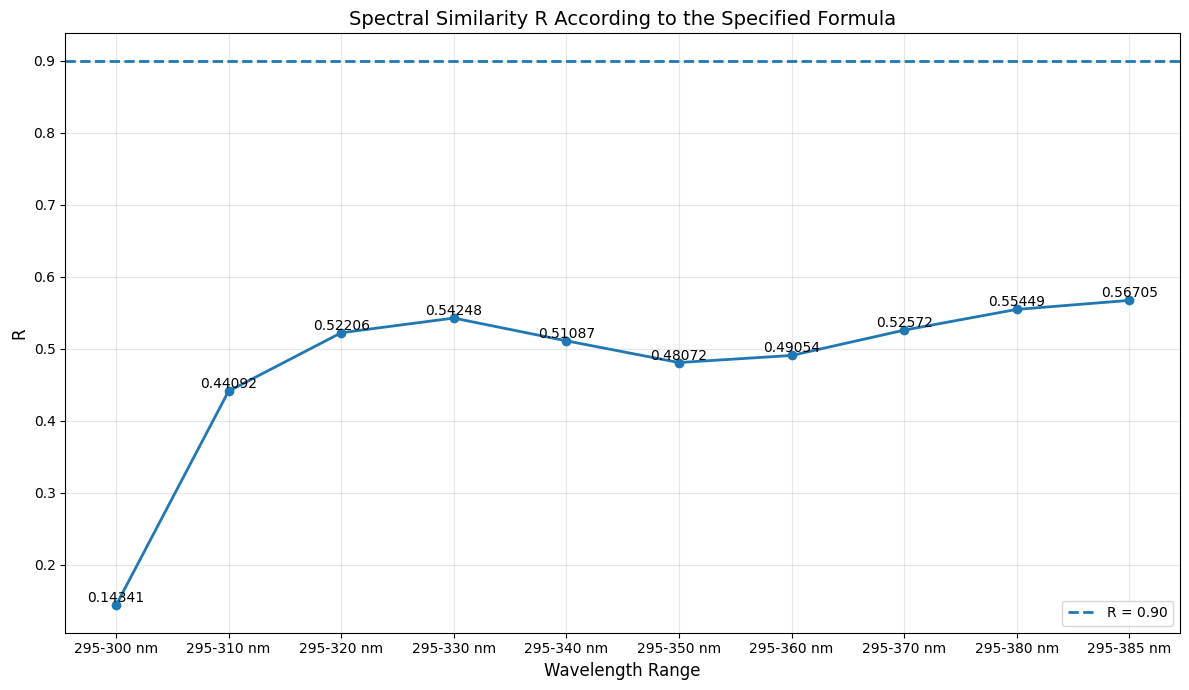




FINAL SUMMARY
     295-300 nm | R = 0.14341448 | R > 0.90: NO
     295-310 nm | R = 0.44092441 | R > 0.90: NO
     295-320 nm | R = 0.52205694 | R > 0.90: NO
     295-330 nm | R = 0.54247695 | R > 0.90: NO
     295-340 nm | R = 0.51086839 | R > 0.90: NO
     295-350 nm | R = 0.48072207 | R > 0.90: NO
     295-360 nm | R = 0.49054342 | R > 0.90: NO
     295-370 nm | R = 0.52572174 | R > 0.90: NO
     295-380 nm | R = 0.55449315 | R > 0.90: NO
     295-385 nm | R = 0.56704516 | R > 0.90: NO

Completed.


In [5]:
# ============================================================
# EXACT R CALCULATION ACCORDING TO THE FORMULA
#
# Formula:
#
# R = 1 - sqrt(
#       Sum[
#           (I_reference - I_UVA340)^2
#           / I_reference
#       ]
#       /
#       (x - 295)
#     )
#
# Reference:
# ASTM G173-03 AM1.5 Global
# from pvlib
#
# UVA-340:
# Q-Lab spectral data
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

!pip install pvlib openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib


# ============================================================
# 2. FILE PATH – Q-LAB UVA-340
# ============================================================

uva_file = (
    "/content/drive/MyDrive/Python_study/"
    "datasets/UVA340_QLab.csv"
)


# ============================================================
# 3. READ Q-LAB UVA-340
# ============================================================

uva = pd.read_csv(
    uva_file
)

uva.columns = (
    uva.columns
    .str.strip()
)


# ============================================================
# 4. CHECK COLUMNS
# ============================================================

required_columns = [
    "Wavelength_nm",
    "I_UVA340"
]

missing = [
    col
    for col in required_columns
    if col not in uva.columns
]

if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )


# ============================================================
# 5. CONVERT TO NUMERIC
# ============================================================

uva["Wavelength_nm"] = pd.to_numeric(
    uva["Wavelength_nm"],
    errors="coerce"
)

uva["I_UVA340"] = pd.to_numeric(
    uva["I_UVA340"],
    errors="coerce"
)


# ============================================================
# 6. CLEAN DATA
# ============================================================

uva = uva.dropna(
    subset=[
        "Wavelength_nm",
        "I_UVA340"
    ]
).copy()


# Sort
uva = uva.sort_values(
    "Wavelength_nm"
)


# If duplicate wavelength exists,
# calculate mean

uva = uva.groupby(
    "Wavelength_nm",
    as_index=False
)["I_UVA340"].mean()


# ============================================================
# 7. WAVELENGTH SETTINGS
# ============================================================

lambda_min = 295

lambda_max_list = [
    300,
    310,
    320,
    330,
    340,
    350,
    360,
    370,
    380,
    385
]


# ============================================================
# 8. GET ASTM G173-03
# ============================================================

am15 = (
    pvlib.spectrum.get_reference_spectra(
        standard="ASTM G173-03"
    )
)


# ============================================================
# 9. SELECT AM1.5 GLOBAL
# ============================================================

I_AM15_global = (
    am15["global"]
)


# ============================================================
# 10. LIMIT UVA-340 DATA
# ============================================================

uva = uva[
    (
        uva["Wavelength_nm"]
        >= lambda_min
    )
    &
    (
        uva["Wavelength_nm"]
        <= max(lambda_max_list)
    )
].copy()


# ============================================================
# 11. INTERPOLATE AM1.5
#     TO EXACT UVA-340 WAVELENGTHS
# ============================================================

AM15_interp = np.interp(
    uva["Wavelength_nm"].values,
    am15.index.values,
    I_AM15_global.values
)


# ============================================================
# 12. CREATE COMMON DATAFRAME
# ============================================================

spectra = pd.DataFrame({

    "Wavelength_nm":
        uva["Wavelength_nm"].values,

    "I_UVA340":
        uva["I_UVA340"].values,

    "I_AM15":
        AM15_interp

})


# ============================================================
# 13. CALCULATE R
#     EXACTLY ACCORDING TO THE FORMULA
# ============================================================

results = []

detail_results = {}


for x in lambda_max_list:


    # --------------------------------------------------------
    # Select wavelength 295 → x
    # --------------------------------------------------------

    df_range = spectra[
        (
            spectra["Wavelength_nm"]
            >= lambda_min
        )
        &
        (
            spectra["Wavelength_nm"]
            <= x
        )
    ].copy()


    # --------------------------------------------------------
    # Remove AM1.5 <= 0
    # --------------------------------------------------------

    df_range = df_range[
        df_range["I_AM15"] > 0
    ].copy()


    if len(df_range) < 2:

        print(
            f"Not enough data for "
            f"{lambda_min}-{x} nm"
        )

        continue


    # ========================================================
    # FORMULA:
    #
    # (I_AM15 - I_UVA340)^2 / I_AM15
    # ========================================================

    df_range["Difference"] = (
        df_range["I_AM15"]
        -
        df_range["I_UVA340"]
    )


    df_range["Squared_Difference"] = (
        df_range["Difference"] ** 2
    )


    df_range["Chi_Square_Term"] = (
        df_range["Squared_Difference"]
        /
        df_range["I_AM15"]
    )


    # ========================================================
    # SUM
    #
    # Σ [(I_AM15 - I_UVA340)^2 / I_AM15]
    # ========================================================

    chi_square_sum = (
        df_range[
            "Chi_Square_Term"
        ].sum()
    )


    # ========================================================
    # DENOMINATOR
    #
    # x - 295
    #
    # IMPORTANT:
    # This follows the formula exactly.
    # ========================================================

    denominator = (
        x - lambda_min
    )


    # ========================================================
    # VALUE INSIDE SQRT
    # ========================================================

    sqrt_argument = (
        chi_square_sum
        /
        denominator
    )


    # ========================================================
    # SQUARE ROOT
    # ========================================================

    standard_deviation = np.sqrt(
        sqrt_argument
    )


    # ========================================================
    # R
    #
    # R = 1 - sqrt(...)
    # ========================================================

    R = (
        1
        -
        standard_deviation
    )


    # ========================================================
    # R > 0.90
    # ========================================================

    if R > 0.90:

        threshold = "YES"

    else:

        threshold = "NO"


    # ========================================================
    # SAVE RESULT
    # ========================================================

    results.append({

        "Wavelength_Range":
            f"{lambda_min}-{x} nm",

        "Lambda_Min_nm":
            lambda_min,

        "Lambda_Max_nm":
            x,

        "Data_Points":
            len(df_range),

        "Chi_Square_Sum":
            chi_square_sum,

        "Denominator_x_minus_295":
            denominator,

        "Square_Root_Value":
            standard_deviation,

        "R":
            R,

        "R > 0.90":
            threshold

    })


    # Save detailed calculation
    detail_results[
        f"{lambda_min}-{x}"
    ] = df_range.copy()


# ============================================================
# 14. RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(
    results
)


# Sort by wavelength

results_df = results_df.sort_values(
    "Lambda_Max_nm"
).reset_index(drop=True)


# ============================================================
# 15. DISPLAY RESULTS
# ============================================================

print("\n")

print("=" * 120)

print(
    "R CALCULATION ACCORDING TO THE SPECIFIED FORMULA"
)

print("=" * 120)


print(
    results_df.to_string(
        index=False,
        float_format=lambda x:
        f"{x:.8f}"
    )
)


# ============================================================
# 16. DISPLAY R > 0.90
# ============================================================

qualified = results_df[
    results_df["R"] > 0.90
].copy()


print("\n\n")

print("=" * 100)

print(
    "WAVELENGTH RANGES WITH R > 0.90"
)

print("=" * 100)


if len(qualified) > 0:

    print(
        qualified[
            [
                "Wavelength_Range",
                "R",
                "Chi_Square_Sum",
                "Square_Root_Value"
            ]
        ].to_string(
            index=False,
            float_format=lambda x:
            f"{x:.8f}"
        )
    )

else:

    print(
        "Không có dải nào có R > 0.90."
    )


# ============================================================
# 17. EXPORT CSV
# ============================================================

results_df.to_csv(
    "UVA340_AM15_R_EXACT_FORMULA.csv",
    index=False,
    encoding="utf-8-sig"
)


qualified.to_csv(
    "UVA340_AM15_R_gt_0.90.csv",
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. EXPORT EXCEL
# ============================================================

excel_file = (
    "UVA340_AM15_R_EXACT_FORMULA.xlsx"
)


with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:


    # Summary
    results_df.to_excel(
        writer,
        sheet_name="R_Results",
        index=False
    )


    # R > 0.90
    qualified.to_excel(
        writer,
        sheet_name="R_gt_0_90",
        index=False
    )


    # Synchronized spectra
    spectra.to_excel(
        writer,
        sheet_name="Spectra",
        index=False
    )


    # Detailed calculations
    for range_name, detail_df in (
        detail_results.items()
    ):

        detail_df.to_excel(
            writer,
            sheet_name=(
                range_name + "_nm"
            )[:31],
            index=False
        )


print("\nExcel file:")
print(excel_file)


# ============================================================
# 19. PLOT R VS WAVELENGTH RANGE
# ============================================================

plt.figure(
    figsize=(12, 7)
)


plt.plot(
    results_df[
        "Wavelength_Range"
    ],
    results_df["R"],
    marker="o",
    linewidth=2
)


# Threshold

plt.axhline(
    y=0.90,
    linestyle="--",
    linewidth=2,
    label="R = 0.90"
)


# Display values

for i, row in (
    results_df.iterrows()
):

    plt.text(
        i,
        row["R"],
        f"{row['R']:.5f}",
        ha="center",
        va="bottom",
        fontsize=10
    )


plt.xlabel(
    "Wavelength Range",
    fontsize=12
)

plt.ylabel(
    "R",
    fontsize=12
)

plt.title(
    "Spectral Similarity R "
    "According to the Specified Formula",
    fontsize=14
)


plt.grid(
    True,
    alpha=0.3
)

plt.legend()


plt.tight_layout()


plt.savefig(
    "R_Exact_Formula_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n\n")

print("=" * 100)

print(
    "FINAL SUMMARY"
)

print("=" * 100)


for _, row in (
    results_df.iterrows()
):

    print(
        f"{row['Wavelength_Range']:>15}"
        f" | R = {row['R']:.8f}"
        f" | R > 0.90: "
        f"{row['R > 0.90']}"
    )


print("\nCompleted.")